In [8]:
#1.Data Ingestion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
df.shape

(541909, 8)

In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [11]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [12]:
#Unique records
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [13]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [14]:
#Total orders per country
df['Country'].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [15]:
invalid_dates = df[pd.to_datetime(df['InvoiceDate'], errors='coerce').isna()]

In [17]:
#3.Data Cleaning
#Total null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
df.isnull().sum().sum()

np.int64(136534)

In [19]:
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [20]:
#Missing customerid
df[df["CustomerID"].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,12/1/2010 14:32,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,12/1/2010 14:32,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,12/1/2010 14:32,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,12/1/2010 14:32,0.43,NaN,United Kingdom


In [21]:
df[df["CustomerID"].isnull()]["Quantity"].describe()

count    135080.000000
mean          1.995573
std          66.696153
min       -9600.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        5568.000000
Name: Quantity, dtype: float64

In [22]:
#Missing description and customerid
df[df["CustomerID"].isnull()]["Description"].isnull().sum()

np.int64(1454)

In [23]:
#Blank rows and columns
df.isnull().all(axis=1).sum()

np.int64(0)

In [24]:
df[df.isnull().all(axis=1)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [25]:
#Missing CustomerId
missing_customer = df["CustomerID"].isnull().sum()
total_rows = len(df)

missing_customer / total_rows * 100

np.float64(24.926694334288598)

In [26]:
#How many unique invoices have missing customerid
df[df["CustomerID"].isnull()]["InvoiceNo"].nunique()

3710

In [27]:
#Missing Description
df[df["Description"].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,12/1/2010 14:35,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,12/1/2010 14:35,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom


In [28]:
#StockCode with missing descriptions
df[df["Description"].isnull()]["StockCode"].value_counts().head(10)

StockCode
35965    10
23084    10
22084     9
22451     6
22501     5
21784     5
21033     5
21067     5
23348     5
22866     5
Name: count, dtype: int64

In [29]:
df[df["Description"].isnull()]["UnitPrice"].value_counts()

UnitPrice
0.0    1454
Name: count, dtype: int64

In [30]:
df[df["Description"].isnull()]["Quantity"].describe()

count    1454.000000
mean       -9.359697
std       243.238758
min     -3667.000000
25%       -24.000000
50%        -3.000000
75%         4.000000
max      5568.000000
Name: Quantity, dtype: float64

In [31]:
df[df["Description"].isnull()]["CustomerID"].notna().sum()

np.int64(0)

In [32]:
# Finds rows where trailing/leading spaces exist
df[df['Country'] != df['Country'].str.strip()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [33]:
#Total duplicates
df.duplicated().sum()

np.int64(5268)

In [34]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,12/1/2010 11:49,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,12/1/2010 11:49,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,12/1/2010 11:49,3.75,17920.0,United Kingdom


In [35]:
#Data Types
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [36]:
#Transaction and price validations
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [37]:
(df["Quantity"] <=0).sum() 

np.int64(10624)

In [38]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [39]:
(df["UnitPrice"] <=0).sum()

np.int64(2517)

In [40]:
#Invoices Numbers
df[df["Quantity"] < 0]["InvoiceNo"].head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: object

In [41]:
#Negative quantity rows that ahve invoices starting with C
df[df["Quantity"] < 0]["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [42]:
#Description sinvolved in -ve transactions
df[df["Quantity"] < 0]["Description"].head(20)

141                                Discount
154         SET OF 3 COLOURED  FLYING DUCKS
235          PLASTERS IN TIN CIRCUS PARADE 
236        PACK OF 12 PINK PAISLEY TISSUES 
237        PACK OF 12 BLUE PAISLEY TISSUES 
238       PACK OF 12 RED RETROSPOT TISSUES 
239             CHICK GREY HOT WATER BOTTLE
240        PLASTERS IN TIN VINTAGE PAISLEY 
241                  PLASTERS IN TIN SKULLS
939                JAM MAKING SET WITH JARS
1441              HAND WARMER RED RETROSPOT
1442              CHARLOTTE BAG SUKI DESIGN
1973             3 HOOK HANGER MAGIC GARDEN
1974          5 HOOK HANGER MAGIC TOADSTOOL
1975    SET/5 RED RETROSPOT LID GLASS BOWLS
1976      SET OF SALT AND PEPPER TOADSTOOLS
1977                     DELUXE SEWING KIT 
1978            TRIPLE PHOTO FRAME CORNICE 
1979      RETROSPOT PARTY BAG + STICKER SET
1980           HOOK, 1 HANGER ,MAGIC GARDEN
Name: Description, dtype: object

In [43]:
#2517 rows with -ve prices
df[df["UnitPrice"] <= 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


In [44]:
#Quantity less than 0
(df["Quantity"] < 0).sum()

np.int64(10624)

In [45]:
#Quantity equal to 0
(df["Quantity"] == 0).sum()

np.int64(0)

In [46]:
#Unit price equal to 0
(df["UnitPrice"] == 0).sum()

np.int64(2515)

In [47]:
#unit price < 0
(df["UnitPrice"] < 0).sum()

np.int64(2)

In [48]:
#Data on the unit price < 0
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [49]:
#Zero price transactions that have description
df[(df["UnitPrice"] == 0) & (df["Description"].notna())][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,CustomerID
6391,536941,22734,amazon,20,NaN
6392,536942,22139,amazon,15,NaN
7313,537032,21275,?,-30,NaN
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12647.0
13217,537425,84968F,check,-20,NaN
13218,537426,84968E,check,-35,NaN
13264,537432,35833G,damages,-43,NaN
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,NaN
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,NaN
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,NaN


In [50]:
#Zero price transactions that have a customer
df[df["UnitPrice"] ==0]["Description"].value_counts().head(20)

Description
check                              159
?                                   47
damages                             45
damaged                             43
found                               25
sold as set on dotcom               20
adjustment                          16
Damaged                             14
Unsaleable, destroyed.               9
thrown away                          9
FRENCH BLUE METAL DOOR SIGN 1        9
amazon                               8
FRENCH BLUE METAL DOOR SIGN 8        8
Found                                8
FRENCH BLUE METAL DOOR SIGN 4        7
RECIPE BOX PANTRY YELLOW DESIGN      7
Amazon                               7
FRENCH BLUE METAL DOOR SIGN No       7
??                                   7
OWL DOORSTOP                         7
Name: count, dtype: int64

In [51]:
#How many have a missing customers
df[df["UnitPrice"] ==0]["CustomerID"].notna().sum()

np.int64(40)

In [52]:
#Invoice number that has C
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [53]:
#Cancellation invoices that exists
df[df["InvoiceNo"].astype(str).str.startswith("C")]["Quantity"].describe()

count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [54]:
#Copy of the Dataset
df_clean = df.copy()

In [55]:
df_clean.shape

(541909, 8)

In [56]:
#Removing Duplicates
df_clean =df_clean.drop_duplicates()

In [57]:
df_clean.shape

(536641, 8)

In [58]:
df_clean.duplicated().sum()

np.int64(0)

In [59]:
#Remove unit price not equal to 0
df_clean = df_clean[df_clean["UnitPrice"] !=0]

In [60]:
df_clean.shape

(534131, 8)

In [61]:
#Remove -ve price rows
df_clean = df_clean[df_clean["UnitPrice"] >= 0]

In [62]:
df_clean.shape

(534129, 8)

In [63]:
#Concvert InvoiceDate to a proper Datatype
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [64]:
df_clean["InvoiceDate"].dtype

dtype('<M8[ns]')

In [65]:
#Convert customerid to nullable integer type since we dont want it as float
df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64")

In [66]:
df_clean["CustomerID"].dtype

Int64Dtype()

In [67]:
df_clean.shape

(534129, 8)

In [68]:
#Check missing values
df_clean.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132565
Country             0
dtype: int64

In [69]:
#Check duplicates
df_clean.duplicated().sum()

np.int64(0)

In [70]:
#Check 0/-ve prices
(df_clean["UnitPrice"] <= 0).sum()

np.int64(0)

In [71]:
#Data types
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              Int64
Country                object
dtype: object

In [72]:
#EDA PROCESS  Descriptive statistics
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,534129.000000,534129,534129.000000,401564.0
mean,9.916818,2011-07-04 12:02:01.631403776,4.695864,15281.266797
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.0
25%,1.000000,2011-03-28 11:36:00,1.250000,13939.0
50%,3.000000,2011-07-19 15:55:00,2.100000,15145.0
75%,10.000000,2011-10-18 17:10:00,4.130000,16788.0
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0
std,216.452113,NaN,95.079189,1713.978947


In [73]:
#Categorical columns
df_clean.describe(include="object")

,InvoiceNo,StockCode,Description,Country
count,534129,534129,534129,534129
unique,23796,3938,4042,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2295,2353,487806


In [74]:
#% of transactions from each country
(df_clean["Country"].value_counts(normalize=True) * 100).head(10)

Country
United Kingdom    91.327376
Germany            1.774478
France             1.598865
EIRE               1.531465
Spain              0.473107
Netherlands        0.443151
Belgium            0.387360
Switzerland        0.373131
Portugal           0.282703
Australia          0.234962
Name: proportion, dtype: float64

In [75]:
#Uniquie Customers
df_clean["CustomerID"].nunique()

4371

In [76]:
#How many transaction or orders does each customer have
customer_transactions = df_clean["CustomerID"].value_counts()

customer_transactions.head(10)

CustomerID
17841    7812
14911    5896
14096    5128
12748    4458
14606    2759
15311    2478
14646    2081
13089    1853
13263    1667
14298    1640
Name: count, dtype: Int64

In [77]:
#No of unique orders
df_clean["InvoiceNo"].nunique()

23796

In [78]:
#Invoices each customer has
customer_orders = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()

customer_orders.sort_values(ascending=False).head(10)

CustomerID
14911    248
12748    223
17841    169
14606    128
13089    118
15311    118
12971     89
14527     86
13408     81
14646     76
Name: InvoiceNo, dtype: int64

In [79]:
#revenue
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [80]:
#Total Revenue
df_clean["Revenue"].sum()

np.float64(9748131.074)

In [81]:
#Average
df_clean["Revenue"].mean()

np.float64(18.25051827180325)

In [82]:
#Median
df_clean["Revenue"].median()

9.899999999999999

In [83]:
#Highest Revenue Transactions
df_clean.sort_values("Revenue", ascending=False)[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]
].head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06
173382,551697,POST,POSTAGE,1,8142.75,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00


In [84]:
#Lowest Revenue Transactions
df_clean.sort_values("Revenue")[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]
].head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,-168469.60
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,-77183.60
222681,C556445,M,Manual,-1,38970.00,-38970.00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46,-17836.46
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02,-16888.02
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71,-16453.71
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33,-13541.33
16356,C537651,AMAZONFEE,AMAZON FEE,-1,13541.33,-13541.33
16232,C537644,AMAZONFEE,AMAZON FEE,-1,13474.79,-13474.79
524601,C580604,AMAZONFEE,AMAZON FEE,-1,11586.50,-11586.50


In [85]:
#Cancelled invoices
df_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [86]:
# -ve quantity
(df_clean["Quantity"] < 0).sum()

np.int64(9251)

In [87]:
#Most common stock codes
df_clean["StockCode"].value_counts().head(15)

StockCode
85123A    2295
22423     2187
85099B    2153
47566     1719
20725     1626
84879     1488
22197     1468
22720     1465
21212     1367
22383     1327
20727     1323
22457     1272
23203     1259
POST      1252
22386     1245
Name: count, dtype: int64

In [88]:
#Special transaction codes
special_codes = df_clean[df_clean["StockCode"].astype(str).str.contains("POST|AMAZON|FEE|BANK|ADJUST|MANUAL",case=False,na=False)]
special_codes[["StockCode", "Description"]].drop_duplicates().sort_values("StockCode")

,StockCode,Description
14514,AMAZONFEE,AMAZON FEE
4406,BANK CHARGES,Bank Charges
45,POST,POSTAGE


In [90]:
#Total revenue in special transaction codes
df_clean[df_clean["StockCode"].isin(["AMAZONFEE", "BANK CHARGES", "POST", "B", "M"])][["StockCode", "Description", "Revenue"]].groupby(["StockCode", "Description"])["Revenue"].agg(["count", "sum"])

,,count,sum
StockCode,Description,,
AMAZONFEE,AMAZON FEE,34,-221520.500
B,Adjust bad debt,1,11062.060
BANK CHARGES,Bank Charges,37,-7175.639
M,Manual,560,-69034.190
POST,POSTAGE,1252,66230.640


In [91]:
#Product sales dataset that excludes special code transactions
product_sales = df_clean[~df_clean["StockCode"].isin(["AMAZONFEE", "BANK CHARGES", "POST", "B", "M"])].copy()

In [92]:
product_sales.shape

(532245, 9)

In [93]:
#Gross sales vs net sales
#Gross sales- represents sales before subtracting returns(What customer purchased)
gross_sales = product_sales.loc[product_sales["Quantity"] > 0, "Revenue"].sum()
gross_sales

np.float64(10461270.502999999)

In [94]:
#Total value of returned items returns(Value reversed /refunded)
returns = product_sales.loc[product_sales["Quantity"] < 0, "Revenue"].sum()
returns

np.float64(-492701.80000000005)

In [95]:
#Net sales = gross sales + returns(what remains after returns)
net_sales = gross_sales + returns
net_sales

np.float64(9968568.702999998)

In [96]:
#Return rate by value(what % of gross sales was returned)
return_rate = abs(returns) / gross_sales * 100
return_rate

np.float64(4.709770193388145)

In [97]:
#Sales over time
product_sales["Month"] = product_sales["InvoiceDate"].dt.to_period("M")

In [98]:
#Net sales by  month
monthly_sales = product_sales.groupby("Month")["Revenue"].sum()
monthly_sales

Month
2010-12     782681.900
2011-01     592959.970
2011-02     508712.920
2011-03     691576.200
2011-04     488119.361
2011-05     741239.430
2011-06     735415.820
2011-07     690072.381
2011-08     713368.270
2011-09    1025977.841
2011-10    1077865.270
2011-11    1461227.880
2011-12     459351.460
Freq: M, Name: Revenue, dtype: float64

In [99]:
#Which products generate most revenues
top_products = product_sales.groupby(["StockCode", "Description"])["Revenue"].sum().sort_values(ascending=False)
top_products.head(10)

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206245.48
22423      REGENCY CAKESTAND 3 TIER              164459.49
47566      PARTY BUNTING                          98243.88
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97659.94
85099B     JUMBO BAG RED RETROSPOT                92175.79
23084      RABBIT NIGHT LIGHT                     66661.63
22086      PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
84879      ASSORTED COLOUR BIRD ORNAMENT          58792.42
79321      CHILLI LIGHTS                          53746.66
23298      SPOTTY BUNTING                         42030.67
Name: Revenue, dtype: float64

In [100]:
df_clean[df_clean["StockCode"] == "DOT"][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]].head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
1814,536544,DOT,DOTCOM POSTAGE,1,569.77,569.77
3041,536592,DOT,DOTCOM POSTAGE,1,607.49,607.49
5450,536862,DOT,DOTCOM POSTAGE,1,254.43,254.43
5545,536864,DOT,DOTCOM POSTAGE,1,121.06,121.06
5685,536865,DOT,DOTCOM POSTAGE,1,498.47,498.47
6165,536876,DOT,DOTCOM POSTAGE,1,887.52,887.52
10812,537237,DOT,DOTCOM POSTAGE,1,863.74,863.74
11381,537240,DOT,DOTCOM POSTAGE,1,940.87,940.87
13924,537434,DOT,DOTCOM POSTAGE,1,950.99,950.99
15650,537638,DOT,DOTCOM POSTAGE,1,836.14,836.14


In [101]:
df_clean[df_clean["StockCode"] == "DOT"]["Revenue"].agg(["count", "sum"])

count       707.00
sum      206245.48
Name: Revenue, dtype: float64

In [102]:
product_sales = df_clean[~df_clean["StockCode"].isin(["AMAZONFEE", "BANK CHARGES", "POST", "B", "M", "DOT"])].copy()

In [103]:
product_sales.shape

(531538, 9)

In [104]:
top_products = product_sales.groupby(["StockCode", "Description"])["Revenue"].sum().sort_values(ascending=False)
top_products.head(10)

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              164459.49
47566      PARTY BUNTING                          98243.88
85123A     WHITE HANGING HEART T-LIGHT HOLDER     97659.94
85099B     JUMBO BAG RED RETROSPOT                92175.79
23084      RABBIT NIGHT LIGHT                     66661.63
22086      PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
84879      ASSORTED COLOUR BIRD ORNAMENT          58792.42
79321      CHILLI LIGHTS                          53746.66
23298      SPOTTY BUNTING                         42030.67
22386      JUMBO BAG PINK POLKADOT                41584.43
Name: Revenue, dtype: float64

In [105]:
top_quantity = product_sales.groupby(["StockCode", "Description"])["Quantity"].sum().sort_values(ascending=False)
top_quantity.head(10)

StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
85099B     JUMBO BAG RED RETROSPOT               47256
22197      POPCORN HOLDER                        36322
84879      ASSORTED COLOUR BIRD ORNAMENT         36282
21212      PACK OF 72 RETROSPOT CAKE CASES       36016
85123A     WHITE HANGING HEART T-LIGHT HOLDER    35002
23084      RABBIT NIGHT LIGHT                    30631
22492      MINI PAINT SET VINTAGE                26437
22616      PACK OF 12 LONDON TISSUES             26095
21977      PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

In [106]:
#Top customer by revenue
top_customers = product_sales.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
top_customers.head(10)

CustomerID
14646    278571.62
18102    259657.30
17450    189490.73
14911    132458.73
12415    123638.18
14156    114335.77
17511     88138.20
16684     65892.08
13694     62714.54
16029     60177.89
Name: Revenue, dtype: float64

In [107]:
order_values = product_sales.groupby(["CustomerID", "InvoiceNo"])["Revenue"].sum()
order_values.head()

CustomerID  InvoiceNo
12346       541431       77183.60
            C541433     -77183.60
12347       537626         711.79
            542237         475.39
            549222         636.25
Name: Revenue, dtype: float64

In [108]:
#Average order value
aov = order_values.mean()
aov

np.float64(377.6342440440807)

In [109]:
#AOV Excluding return orders/cancelled
positive_orders = order_values[order_values > 0]
positive_aov = positive_orders.mean()
positive_aov

np.float64(475.0835991850041)

In [110]:
aov = order_values.mean()
positive_orders = order_values[order_values > 0]
positive_aov = positive_orders.mean()
aov, positive_aov

(np.float64(377.6342440440807), np.float64(475.0835991850041))

In [111]:
#Customers with missing ids
product_sales["CustomerID"].isna().sum()

np.int64(131652)

In [112]:
product_sales["CustomerID"].notna().sum()

np.int64(399886)

In [113]:
product_sales["CustomerID"].isna().mean() * 100

np.float64(24.768125703148222)

In [114]:
#Revenue by country
country_sales = product_sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    8267551.663
Netherlands        283273.140
EIRE               264120.510
Germany            200619.660
France             182262.600
Australia          136922.500
Switzerland         52483.050
Spain               51746.650
Belgium             36662.960
Japan               35419.790
Name: Revenue, dtype: float64

In [115]:
(product_sales["UnitPrice"] <= 0).sum()

np.int64(0)

In [116]:
(product_sales["Quantity"] == 0).sum()

np.int64(0)

In [117]:
product_sales.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131652
Country             0
Revenue             0
dtype: int64

In [118]:
#Creating a final dataset
df_final = product_sales.copy()

In [119]:
df_final.reset_index(drop=True, inplace=True)

In [120]:
df_final.shape

(531538, 9)

In [121]:
df_final.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [122]:
#Saving cleaned dataset/creating a csv file
df_final.to_csv("OnlineRetail_Cleaned.csv",index=False)

In [123]:
import os
os.path.getsize("OnlineRetail_Cleaned.csv")

50790622

In [124]:
df_check = pd.read_csv("OnlineRetail_Cleaned.csv")

df_check.shape

(531538, 9)

In [125]:
df_check.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# E-commerce Dataset — EDA Findings So Far

## 1. Data Quality
- The original dataset contained **541,909 rows and 8 columns**.
- After the initial cleaning process, **534,129 rows** remained.
- Invalid negative unit prices were identified and removed.
- Zero-price transactions were investigated and handled appropriately.
- Negative quantities were investigated as returns and other special transactions.
- The final product-sales dataset contains **531,538 rows and 9 columns**.
- No missing values remain in the main transaction, product, quantity, date, price, country, or revenue fields.
- **131,652 CustomerID values are missing**, which limits customer-level analysis.

## 2. Sales Performance
- Gross product sales were approximately **10.46 million**.
- Returns amounted to approximately **-492,701.80**.
- Net product sales were approximately **9.97 million**.
- The return rate by value was approximately **4.71%**.
- The average positive order value was approximately **475.08**.

## 3. Sales Trends
- **November 2011** recorded the highest monthly net revenue at approximately **1.46 million**.
- Revenue increased considerably between **September and November 2011**.
- December 2011 is incomplete because the dataset ends on **December 9, 2011**.
- Therefore, December should not be directly compared with complete months.

## 4. Product Performance
- **REGENCY CAKESTAND 3 TIER** generated the highest product revenue at approximately **164,459.49**.
- **WORLD WAR 2 GLIDERS ASSTD DESIGNS** had the highest quantity sold at approximately **53,751 units**.
- High-volume products do not necessarily generate the highest revenue because product prices vary.

## 5. Customer Performance
- **Customer 14646** generated the highest net revenue at approximately **278,571.62**.
- Customer purchase frequency and customer revenue represent different aspects of customer performance and should be analyzed separately.

## 6. Geographic Performance
- The **United Kingdom** was the dominant market, generating approximately **8.27 million** in net product revenue.
- The **Netherlands, EIRE, Germany, and France** were the next largest markets by revenue, although at substantially lower levels than the United Kingdom.

## 7. Special Transactions
- Special transactions such as **postage, Amazon fees, bank charges, manual transactions, and bad-debt adjustments** were identified.
- These transactions were excluded from product-sales analysis to prevent them from distorting product performance.

## 8. EDA Visualizations — Completed
The following visualizations were created to further explore the dataset:

- Monthly revenue trend
- Top 10 products by revenue
- Top 10 products by quantity sold
- Revenue by country

## 9. Final Business Insights — Completed
The final 3–5 business insights will be developed after completing and interpreting the EDA visualizations.

In [126]:
monthly_revenue = df_final.groupby(df_final["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()
monthly_revenue

InvoiceDate
2010-12     758010.710
2011-01     579041.440
2011-02     498652.350
2011-03     679746.490
2011-04     480583.981
2011-05     731010.130
2011-06     723567.160
2011-07     677231.381
2011-08     699967.750
2011-09    1010800.441
2011-10    1059910.140
2011-11    1424322.480
2011-12     439478.770
Freq: M, Name: Revenue, dtype: float64

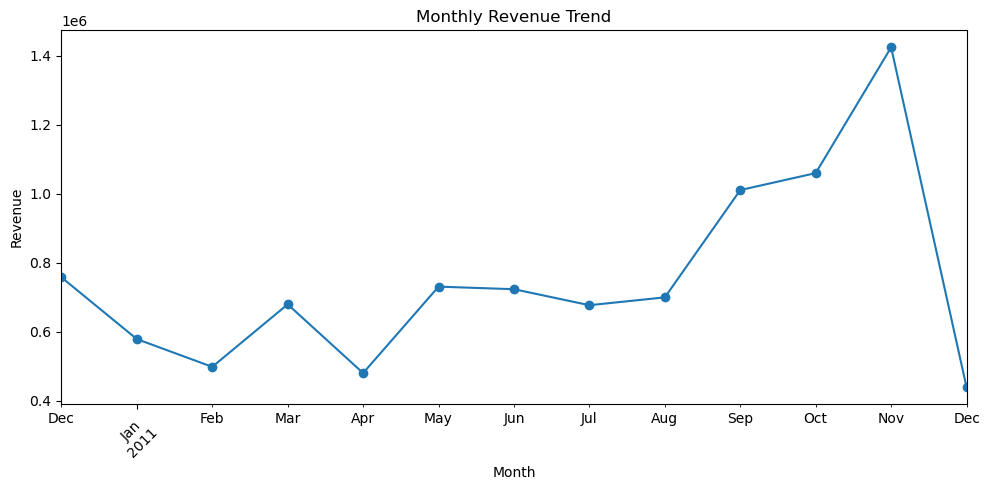

In [127]:
#Monthly Revenue
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Monthly Revenue Trend

The monthly revenue trend shows how sales changed over the period
from December 2010 to December 2011.

November 2011 recorded the highest monthly revenue, while December
2011 should be interpreted carefully because the dataset ends on
December 9, 2011.

In [134]:
#Top 10 Products By Revenue
top_products = df_final.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
SPOTTY BUNTING                         42030.67
JUMBO BAG PINK POLKADOT                41584.43
Name: Revenue, dtype: float64

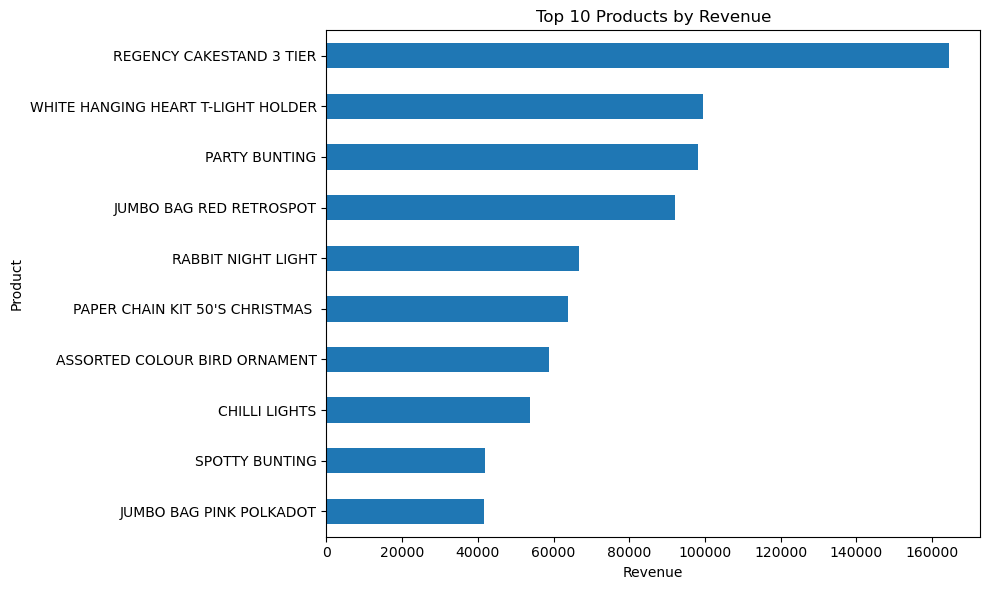

In [147]:
#Bar Chart representing products by revenue
import matplotlib.pyplot as plt

top_products.sort_values().plot( kind="barh", figsize=(10, 6))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Interpretation

The chart shows the top 10 products ranked by total revenue. 
REGENCY CAKESTAND 3 TIER generated the highest revenue among the products shown, 
followed by WHITE HANGING HEART T-LIGHT HOLDER and PARTY BUNTING. 
The remaining products contributed lower amounts of revenue, 
showing that revenue is concentrated among a small number of top-performing products.

In [135]:
#Top 10 countries by revenue
country_revenue = (df_final.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10))
country_revenue

Country
United Kingdom    8267551.663
Netherlands        283273.140
EIRE               264120.510
Germany            200619.660
France             182262.600
Australia          136922.500
Switzerland         52483.050
Spain               51746.650
Belgium             36662.960
Japan               35419.790
Name: Revenue, dtype: float64

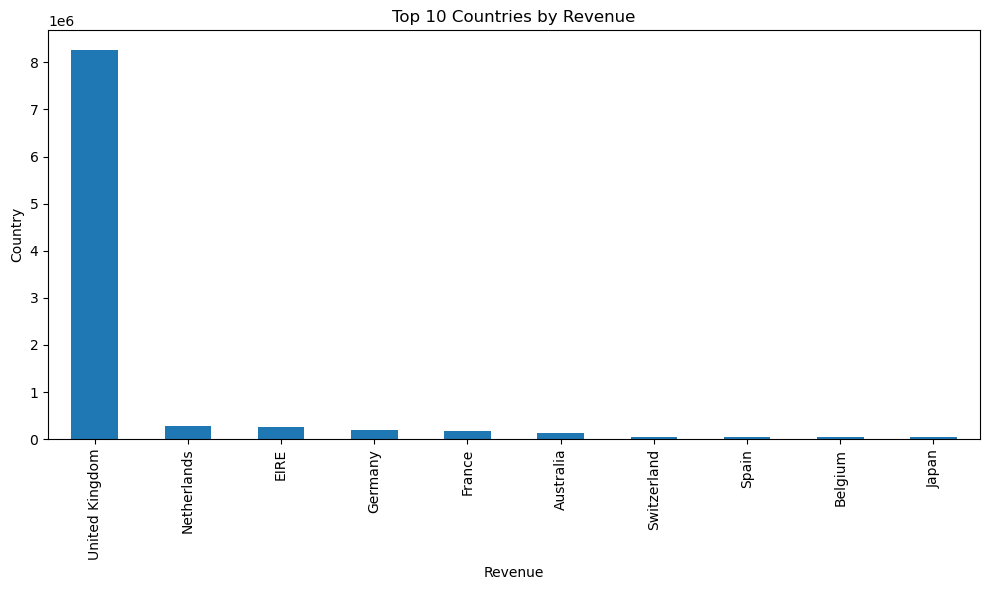

In [143]:
import matplotlib.pyplot as plt

country_revenue.sort_values(ascending=False).plot(kind="bar",figsize=(10, 6))

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Interpretation

The chart shows that the United Kingdom generated by far the highest revenue,
making it the main market in the dataset. The Netherlands ranked second,
although its revenue was substantially lower than that of the United Kingdom.

Other countries such as EIRE, Germany, France, and Australia also contributed
to revenue, but at considerably lower levels. Overall, the revenue distribution
is highly concentrated in the United Kingdom.

In [137]:
top_products_quantity = (df_final.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10))
top_products_quantity

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47256
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
WHITE HANGING HEART T-LIGHT HOLDER    35294
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26095
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

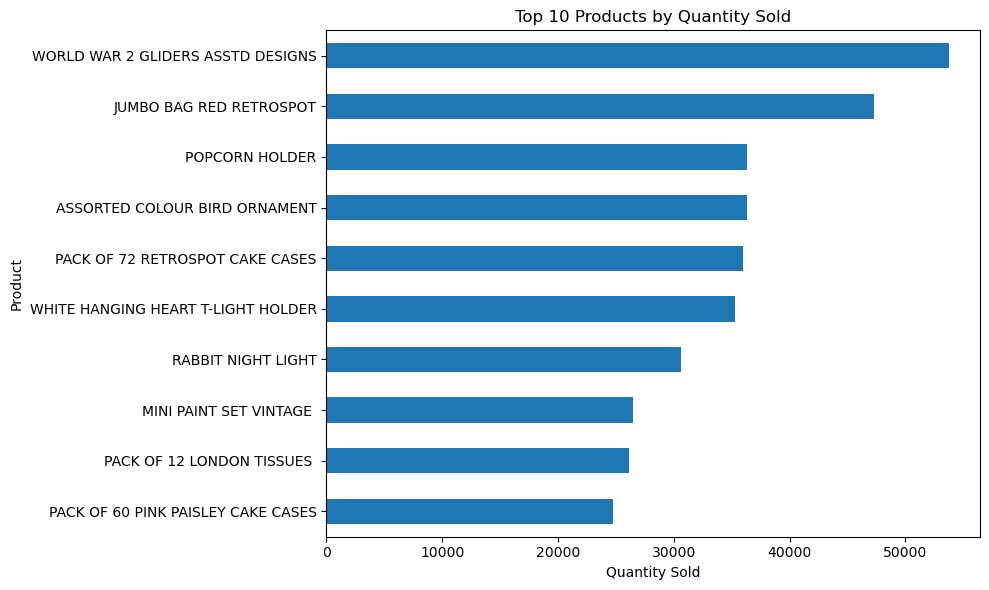

In [148]:
top_products_quantity.sort_values().plot(kind="barh",figsize=(10, 6))

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## Interpretation

This visualization identifies the products with the highest total quantity sold.
Comparing quantity sold with product revenue helps determine whether high sales volume translates into high revenue.

# Final Business Insights 💡

Based on the data analysis and visualizations, the following key business insights were identified:

1. **Revenue trend:** Monthly revenue increased toward the end of the available period, with November 2011 recording the highest monthly revenue.

2. **Product revenue:** REGENCY CAKESTAND 3 TIER generated the highest revenue among the products analyzed, showing strong revenue contribution from this product.

3. **Product demand:** WORLD WAR 2 GLIDERS ASSTD DESIGNS had the highest quantity sold, demonstrating that the product with the highest sales volume is not necessarily the product generating the highest revenue.

4. **Geographic performance:** The United Kingdom was the dominant market by revenue, significantly outperforming the other countries in the dataset.

5. **Customer data limitation:** A large number of CustomerID values were missing, which limits the reliability of customer-level analysis and should be considered when interpreting customer insights.
